In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Base vs aligned, all 8 models

`pretrained_vs_instruct.ipynb` compared **one** pair (qwen-7B) and found the scale-free weight
vectors agree at `r = 0.990` while the aligned model is ~9x louder. The remaining base models
have now landed, so this asks whether that replicates.

**Answer, in short: it replicates for qwen and cannot be tested for gemma.** Every gemma base
model answers by *slot position* rather than by content, so it has no preference vector to
compare. That is a measurement failure, not evidence against the finding — and Step 1 below is
the gate that decides which models may be interpreted at all.

Method is unchanged: zero-mean weights, frame pinned to `shopping`, every "who wins" question
answered position-corrected. Full notation and a worked synthetic example are in
[explainer_metrics.ipynb](explainer_metrics.ipynb). `scores.csv` is read, never written.

In [2]:
import json, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

SAVE = True
FIGDIR = "figs/base_vs_aligned"
os.makedirs(FIGDIR, exist_ok=True)

BASES = ["data/laptops_robustness", "data/laptops_robustness_gemma", "data/laptops_robustness_pt"]
BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
SC, RM = ["13-inch", "14-inch", "16-inch"], ["4GB", "8GB", "16GB"]
LEVELS = {"brand": BRANDS, "screen": SC, "ram": RM}
CON = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
CLAB = dict(zip(CON, ["none", "14in", "8GB", "14in+8GB"]))
cols = [CLAB[c] for c in CON]
FRAME = "shopping"          # held fixed: every constrained run uses it (see CLAUDE.md)

# (base family, aligned family, size) - the 8 pairs
PAIRS = ([("qwen-pt", "qwen", s) for s in ["0.5", "7", "32", "72"]]
         + [("gemma-pt", "gemma", s) for s in ["1", "4", "12", "27"]])
MODELS = [f"{a}-{s}B" for _, a, s in PAIRS]

BRAND_COLOR = dict(zip(BRANDS, ["#2a78d6", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
BRAND_MARKER = dict(zip(BRANDS, ["o", "s", "^", "D", "v"]))
FEATURE_COLOR = {"brand": "#2a78d6", "screen": "#eb6834", "ram": "#1baf7a"}
KIND_COLOR = {"base": "#8a6bbf", "aligned": "#2a78d6"}
FAM_COLOR = {"qwen": "#2a78d6", "gemma": "#eb6834"}
PASS_C, FAIL_C = "#1baf7a", "#e34948"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#d6d5d1",
    "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "axes.grid": True,
    "grid.color": "#e8e7e3", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.dpi": 110, "font.size": 10, "savefig.bbox": "tight",
    "savefig.dpi": 200,
})
pd.set_option("display.width", 230)

def save(fig, name):
    if SAVE:
        fig.savefig(os.path.join(FIGDIR, name + ".png"), facecolor=SURFACE)
    return fig

## Load

The base runs were collected **after** PMI was turned off, the aligned runs before it. So `C` is
recovered from saturation for the aligned runs and is **exactly 0** for the base runs — verified
below rather than assumed: with PMI off every stored score is a bare log-probability, so all must
be `<= 0`.

In [3]:
def load(frame=FRAME):
    """Keyed by (family, size, constraints_id), frame pinned. scores.csv read, never written."""
    R = {}
    for base in BASES:
        for run in sorted(os.listdir(base)):
            cp = os.path.join(base, run, "config.json")
            if not os.path.isfile(cp):
                continue
            c = json.load(open(cp))
            if c["frame"]["name"] != frame or c["constraints_id"] not in CON:
                continue
            key = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            assert key not in R, f"two runs share the key {key}; the key is not unique"
            R[key] = pd.read_csv(os.path.join(base, run, "scores.csv"))
    return R


def pmi_offset(runs, tol=0.01, min_sat=0.01):
    """C from saturation. NaN when the model never saturates (then gamma is unrecoverable)."""
    mA = max(d.score_a.max() for d in runs)
    mB = max(d.score_b.max() for d in runs)
    sat = min(max((d.score_a > mA - tol).mean() for d in runs),
              max((d.score_b > mB - tol).mean() for d in runs))
    return (mB - mA if sat >= min_sat else np.nan), max(mA, mB)


RUNS = load()
AVAIL = {}            # (family, size) -> contracts actually present
for pf, af, s in PAIRS:
    for fam in (pf, af):
        AVAIL[(fam, s)] = [c for c in CON if (fam, s, c) in RUNS]

PMI_C = {}
rows = []
for pf, af, s in PAIRS:
    cb, mx_b = pmi_offset([RUNS[(pf, s, c)] for c in AVAIL[(pf, s)]])
    ca, mx_a = pmi_offset([RUNS[(af, s, c)] for c in AVAIL[(af, s)]])
    PMI_C[(pf, s)] = 0.0          # PMI was off for the base runs, by construction
    PMI_C[(af, s)] = ca
    rows.append(dict(model=f"{af}-{s}B", base_runs=len(AVAIL[(pf, s)]),
                     aligned_runs=len(AVAIL[(af, s)]), base_max_score=mx_b,
                     base_pmi_off=mx_b <= 0, aligned_C=ca))
print(pd.DataFrame(rows).round(3).to_string(index=False))
assert all(r["base_pmi_off"] for r in rows), "a base run has positive scores - PMI may be on"
print(f"\n{len(RUNS)} runs loaded, frame pinned to {FRAME!r}.")
print("qwen-pt 72B is missing the screen=14-inch run, so it appears with 3 contracts, not 4.")
print("aligned_C is NaN for qwen-0.5B: it never saturates, so its gamma is not recoverable.")

    model  base_runs  aligned_runs  base_max_score  base_pmi_off  aligned_C
qwen-0.5B          4             4          -0.314          True        NaN
  qwen-7B          4             4          -0.001          True      6.001
 qwen-32B          4             4          -0.002          True      2.250
 qwen-72B          3             4          -0.004          True      5.625
 gemma-1B          4             4          -0.192          True     10.468
 gemma-4B          4             4          -0.006          True     10.500
gemma-12B          4             4          -0.006          True      9.749
gemma-27B          4             4          -0.004          True      5.243

63 runs loaded, frame pinned to 'shopping'.
qwen-pt 72B is missing the screen=14-inch run, so it appears with 3 contracts, not 4.
aligned_C is NaN for qwen-0.5B: it never saturates, so its gamma is not recoverable.


In [4]:
class FeatureBT:
    """Feature-based Bradley-Terry with a positional bias. See explainer_metrics.ipynb."""

    def __init__(self, pmi_c=0.0):
        self.pmi_c = pmi_c

    def fit(self, df):
        n = len(df)
        Y = (df["score_a"] - df["score_b"]).values
        cols_a = [c for c in df.columns if c.startswith("a_")]
        self.features_ = [c[2:] for c in cols_a]
        A = df[cols_a].rename(columns=dict(zip(cols_a, self.features_)))
        B = df[[f"b_{f}" for f in self.features_]].rename(
            columns={f"b_{f}": f for f in self.features_})
        combined = pd.concat([A, B], axis=0)
        dummies = pd.get_dummies(combined, drop_first=True, dtype=float)
        X = sm.add_constant(dummies.iloc[:n].values - dummies.iloc[n:].values)
        res = sm.OLS(Y, X).fit()
        self.beta0_ = res.params[0]                 # = gamma - C
        self.gamma_ = self.beta0_ + self.pmi_c      # the real positional bias
        self.r2_ = res.rsquared
        self.resid_sd_ = np.std(res.resid)
        raw = dict(zip(dummies.columns.tolist(), res.params[1:]))
        self.weights_ = {}
        for f in self.features_:
            w = {l: raw.get(f"{f}_{l}", 0.0) for l in combined[f].unique()}
            m = np.mean(list(w.values()))
            self.weights_[f] = {l: v - m for l, v in w.items()}
        return self

    def range(self, f):
        w = self.weights_[f]
        return max(w.values()) - min(w.values())

    def total_spread(self):
        return sum(self.range(f) for f in self.features_)

    def normalised(self, f, l):
        return self.weights_[f][l] / self.total_spread()


FITS = {k: FeatureBT(pmi_c=PMI_C[k[:2]]).fit(d) for k, d in RUNS.items()}
print(f"{len(FITS)} fits.")

63 fits.


In [5]:
def paired_D(d, feat, u, v):
    """Position-corrected D per unordered pair, ceteris paribus. + means `u` wins."""
    m = (d.score_a - d.score_b).values
    tie = np.ones(len(d), bool)
    for o in [x for x in ("brand", "screen", "ram") if x != feat]:
        tie &= (d[f"a_{o}"] == d[f"b_{o}"]).values
    pair = (((d[f"a_{feat}"] == u) & (d[f"b_{feat}"] == v))
            | ((d[f"a_{feat}"] == v) & (d[f"b_{feat}"] == u))).values
    is_u = (d[f"a_{feat}"] == u).values
    key = np.char.add(np.char.add(d.a_brand.values, "|"),
          np.char.add(np.where(d.a_screen.values == d.b_screen.values, d.a_screen.values, "x"),
          np.char.add(np.where(d.a_ram.values == d.b_ram.values, d.a_ram.values, "x"),
                      d.template_idx.astype(str).values)))
    t = pd.DataFrame({"k": key, "v": np.where(is_u, m, -m)})[tie & pair]
    g = t.groupby("k")["v"].agg(["mean", "size"])
    return g[g["size"] == 2]["mean"].values


ASKED = {"screen": "14-inch", "ram": "8GB"}
RIVAL = {"screen": "16-inch", "ram": "16GB"}
FRIEND = {"screen": "13-inch", "ram": "4GB"}
RUN_OF = {"screen": "screen=14-inch", "ram": "ram=8GB"}

rows = []
for pf, af, s in PAIRS:
    for fam, kind in [(pf, "base"), (af, "aligned")]:
        for feat in ("screen", "ram"):
            if RUN_OF[feat] not in AVAIL[(fam, s)] or "none" not in AVAIL[(fam, s)]:
                continue
            d1, d0 = RUNS[(fam, s, RUN_OF[feat])], RUNS[(fam, s, "none")]
            Dc1 = paired_D(d1, feat, ASKED[feat], RIVAL[feat])
            Dc0 = paired_D(d0, feat, ASKED[feat], RIVAL[feat])
            Da1 = paired_D(d1, feat, ASKED[feat], FRIEND[feat])
            g0, g1 = Dc0.mean(), Dc1.mean()
            rows.append(dict(model=f"{af}-{s}B", fam=af, size=float(s), kind=kind, feat=feat,
                             n=len(Dc1), before=100 * (Dc0 > 0).mean(),
                             conflict=100 * (Dc1 > 0).mean(), agree=100 * (Da1 > 0).mean(),
                             g0=g0, g1=g1, kappa=1 - g1 / g0))
ADH = pd.DataFrame(rows)
print(f"{len(ADH)} adherence cells (model x kind x feature).")

31 adherence cells (model x kind x feature).


---
# Step 1 — the gate: does the base model measure anything?

**Read this before any comparison below.** A correlation between two weight vectors is only
meaningful if both vectors are measuring something. Two checks, neither of which needs a model
to be *good* — only to be *responsive to the laptops*:

**1. The free-lunch check.** On the AGREE pairs (8GB vs 4GB under an `8GB` contract) the contract
and any sensible RAM preference want the *same* laptop. Obeying costs nothing. Every model that
reads the prompt at all should be near 100%.

**2. Positional bias vs preference range,** $|\gamma| / S$. If the slot artefact is larger than
the model's entire spread of preferences, the answer is mostly determined by *which box the
laptop was printed in*, not by the laptop.

A model failing either check has no preference vector worth correlating.

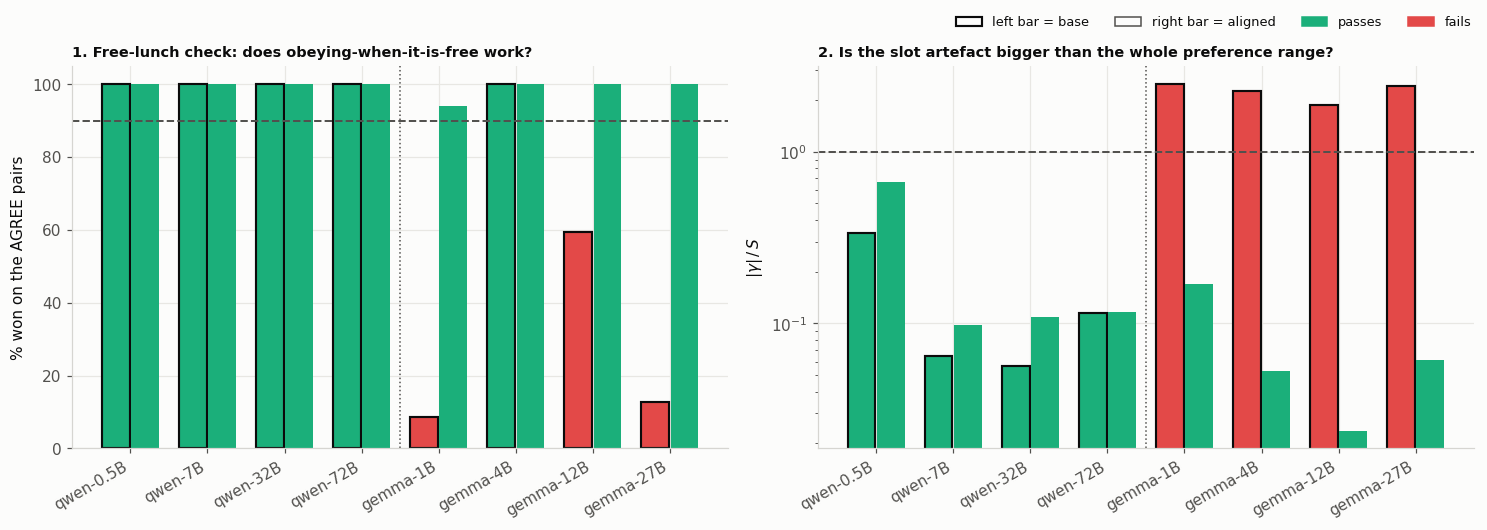

            agree            gamma_over_S                    S                  r2            passes       
kind      aligned       base      aligned      base    aligned      base   aligned      base aligned   base
model                                                                                                      
qwen-0.5B   100.0      100.0     0.668694  0.336285   0.333964  0.289238  0.084762  0.222058    True   True
qwen-7B     100.0      100.0     0.097421  0.064505  31.284307  2.631203  0.864174  0.605156    True   True
qwen-32B    100.0      100.0      0.10841  0.056858  43.662798  2.571048  0.853288  0.525572    True   True
qwen-72B    100.0      100.0     0.117341  0.115149  32.493436  2.635703  0.857066  0.719983    True   True
gemma-1B     94.0   8.666667     0.168906    2.4993   20.88093  0.252754  0.653863  0.041012    True  False
gemma-4B    100.0      100.0     0.053182  2.265395  37.342739  0.625083   0.83167  0.216034    True  False
gemma-12B   100.0  59.333333

In [6]:
gate = []
for pf, af, s in PAIRS:
    m = f"{af}-{s}B"
    for fam, kind in [(pf, "base"), (af, "aligned")]:
        f0 = FITS[(fam, s, "none")]
        ag = ADH[(ADH.model == m) & (ADH.kind == kind)].agree
        gate.append(dict(model=m, fam=af, size=float(s), kind=kind,
                         agree=ag.mean(), gamma_over_S=abs(f0.gamma_ if np.isfinite(f0.gamma_)
                                                           else f0.beta0_) / f0.total_spread(),
                         S=f0.total_spread(), r2=f0.r2_))
G = pd.DataFrame(gate)
G["passes"] = (G.agree >= 90) & (G.gamma_over_S < 1)

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.6))
x = np.arange(len(MODELS))
for ax, (col, ttl, ylab, thr, above_is_good) in zip(axes, [
        ("agree", "1. Free-lunch check: does obeying-when-it-is-free work?",
         "% won on the AGREE pairs", 90, True),
        ("gamma_over_S", "2. Is the slot artefact bigger than the whole preference range?",
         r"$|\gamma| \,/\, S$", 1.0, False)]):
    for i, kind in enumerate(["base", "aligned"]):
        sub = G[G.kind == kind].set_index("model").reindex(MODELS)
        colr = [PASS_C if (v >= thr if above_is_good else v < thr) else FAIL_C
                for v in sub[col]]
        ax.bar(x + (i - .5) * .38, sub[col], .36, color=colr,
               edgecolor=INK if kind == "base" else "none", lw=1.4, zorder=2)
    ax.axhline(thr, color=INK_MUTED, ls="--", lw=1.3)
    ax.set_xticks(x, MODELS, rotation=30, ha="right")
    ax.set_ylabel(ylab)
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=9.5)
    ax.axvline(3.5, color=INK_MUTED, lw=1, ls=":")
axes[1].set_yscale("log")
fig.legend(handles=[Rectangle((0, 0), 1, 1, fc="none", ec=INK, lw=1.4),
                    Rectangle((0, 0), 1, 1, fc="none", ec=INK_MUTED),
                    Rectangle((0, 0), 1, 1, color=PASS_C),
                    Rectangle((0, 0), 1, 1, color=FAIL_C)],
           labels=["left bar = base", "right bar = aligned", "passes", "fails"],
           loc="upper right", ncol=4, frameon=False, fontsize=8.5, bbox_to_anchor=(.995, 1.05))
fig.tight_layout()
save(fig, "a1_gate")
plt.show()

print(G.pivot(index="model", columns="kind",
              values=["agree", "gamma_over_S", "S", "r2", "passes"])
       .reindex(MODELS).round(3).to_string())
print("\nBASE models that pass both checks: ",
      sorted(G[(G.kind == "base") & G.passes].model.tolist()))
print("BASE models that FAIL:               ",
      sorted(G[(G.kind == "base") & ~G.passes].model.tolist()))
print("\nEvery ALIGNED model passes. Every GEMMA base model fails, and fails the same way:")
print("its positional bias is roughly TWICE its entire preference range.")

**The gate splits by family, not by size.** All four qwen base models pass; all four gemma base
models fail, every one of them because $|\gamma|/S \approx 2$ — the slot artefact is about twice
the whole spread of what they prefer. Three of them also fail the free-lunch check outright,
picking the *worse* laptop when the contract and their own taste agree.

The raw margins say the same thing more bluntly. Fraction of rows where the gemma base models
pick slot A, ignoring content entirely: **92%, 99.8%, 12%, 0.6%**. They are answering the
*question format*, not the question.

So for gemma, base-vs-aligned **cannot be measured with this data** — which is different from
"alignment created gemma's preferences". Everything below therefore reports gemma, but greys it
out and does not draw conclusions from it.

In [7]:
PASSES = set(G[(G.kind == "base") & G.passes].model)
print("interpretable pairs:", sorted(PASSES))

# how often does each base model answer by slot alone?
print("\nshare of rows where the model picks slot A (unconstrained run):")
for pf, af, s in PAIRS:
    d = RUNS[(pf, s, "none")]
    m = (d.score_a - d.score_b).values
    print(f"  {af + '-' + s + 'B':10} base  {100 * (m > 0).mean():5.1f}%"
          f"   {'' if f'{af}-{s}B' in PASSES else '  <- content-blind'}")

interpretable pairs: ['qwen-0.5B', 'qwen-32B', 'qwen-72B', 'qwen-7B']

share of rows where the model picks slot A (unconstrained run):
  qwen-0.5B  base   59.0%   
  qwen-7B    base   41.8%   
  qwen-32B   base   60.3%   
  qwen-72B   base   59.2%   
  gemma-1B   base   92.3%     <- content-blind
  gemma-4B   base   99.8%     <- content-blind
  gemma-12B  base   12.4%     <- content-blind
  gemma-27B  base    0.6%     <- content-blind


---
# Step 2 — does `r = 0.990` replicate?

One point per (feature level, contract): 11 levels x 4 contracts = 44 per model (33 for
qwen-pt 72B, which is missing one contract). Axes are the normalised weight
$\tilde{w} = w / S$, so a point on the diagonal means both models give that level the same
share of their total preference range.

Grey panels are the gemma pairs that failed the gate — shown for completeness, not for
interpretation.

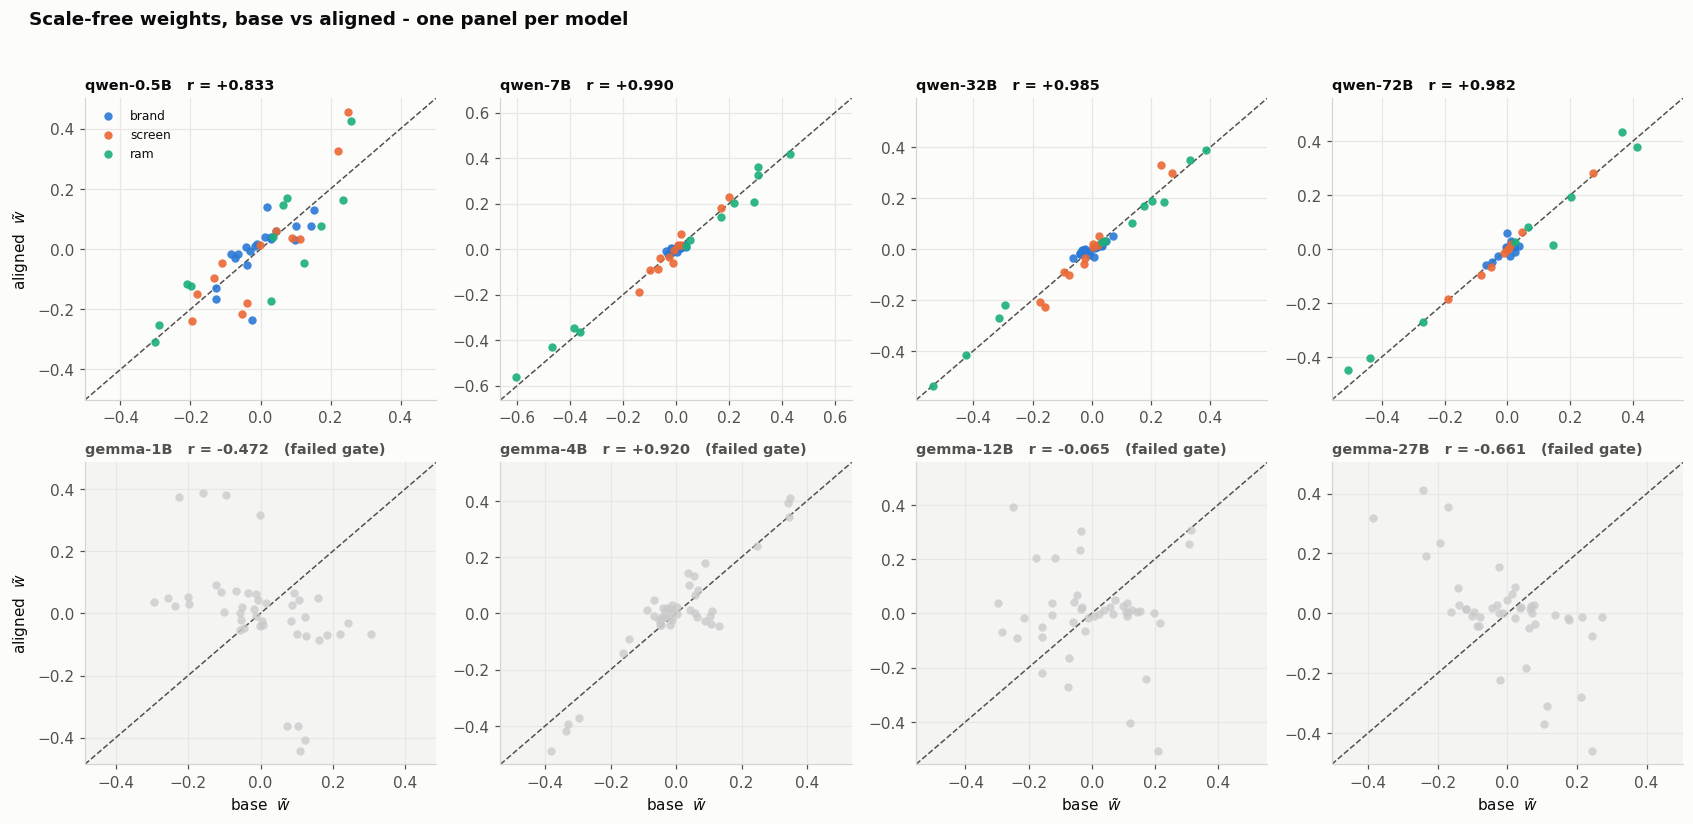

    model   r_all      p  r_brand  n  passes
qwen-0.5B  0.8326 0.0000   0.7093 44    True
  qwen-7B  0.9904 0.0000   0.7901 44    True
 qwen-32B  0.9852 0.0000   0.8666 44    True
 qwen-72B  0.9823 0.0000   0.6721 33    True
 gemma-1B -0.4719 0.0012  -0.4978 44   False
 gemma-4B  0.9204 0.0000  -0.5899 44   False
gemma-12B -0.0654 0.6732   0.1731 44   False
gemma-27B -0.6608 0.0000  -0.1087 44   False

over the 4 interpretable pairs: r ranges 0.833 - 0.990, median 0.984
qwen-7B/32B/72B replicate the 0.99 result. qwen-0.5B is lower (0.83) - both sides of
that pair are near the noise floor (S = 0.29 base, 0.33 aligned), so it is a weak test.


In [8]:
pts = []
for pf, af, s in PAIRS:
    m = f"{af}-{s}B"
    for c in [x for x in CON if x in AVAIL[(pf, s)] and x in AVAIL[(af, s)]]:
        fb, fa = FITS[(pf, s, c)], FITS[(af, s, c)]
        for f, lv in LEVELS.items():
            for l in lv:
                pts.append(dict(model=m, fam=af, size=float(s), con=CLAB[c], feat=f, lvl=l,
                                base=fb.normalised(f, l), aligned=fa.normalised(f, l)))
P = pd.DataFrame(pts)

fig, axes = plt.subplots(2, 4, figsize=(15.5, 7.6))
res = []
for ax, m in zip(axes.ravel(), MODELS):
    s = P[P.model == m]
    ok = m in PASSES
    r, p = st.pearsonr(s.base, s.aligned)
    rb = st.pearsonr(s[s.feat == "brand"].base, s[s.feat == "brand"].aligned)[0]
    res.append(dict(model=m, r_all=r, p=p, r_brand=rb, n=len(s), passes=ok))
    lim = 1.1 * max(s.base.abs().max(), s.aligned.abs().max())
    ax.plot([-lim, lim], [-lim, lim], color=INK_MUTED, lw=1, ls="--", zorder=1)
    for f in LEVELS:
        t = s[s.feat == f]
        ax.scatter(t.base, t.aligned, s=30, zorder=3, linewidths=0,
                   color=FEATURE_COLOR[f] if ok else "#c9c9c9",
                   alpha=.9 if ok else .75, label=f if (m == MODELS[0]) else None)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_title(f"{m}   r = {r:+.3f}" + ("" if ok else "   (failed gate)"),
                 loc="left", fontweight="bold", fontsize=9.5,
                 color=INK if ok else INK_MUTED)
    if not ok:
        ax.set_facecolor("#f4f4f2")
for ax in axes[1]:
    ax.set_xlabel(r"base  $\tilde{w}$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"aligned  $\tilde{w}$")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Scale-free weights, base vs aligned - one panel per model",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, .96])
save(fig, "a2_replication")
plt.show()

RES = pd.DataFrame(res)
print(RES.round(4).to_string(index=False))
good = RES[RES.passes]
print(f"\nover the {len(good)} interpretable pairs: r ranges {good.r_all.min():.3f} - "
      f"{good.r_all.max():.3f}, median {good.r_all.median():.3f}")
print("qwen-7B/32B/72B replicate the 0.99 result. qwen-0.5B is lower (0.83) - both sides of")
print("that pair are near the noise floor (S = 0.29 base, 0.33 aligned), so it is a weak test.")

---
# Step 3 — loudness, and whether it grows with size

$S$ is the model's whole preference range: $u(\text{best laptop}) - u(\text{worst laptop})$.
The loudness ratio $S_{\text{aligned}} / S_{\text{base}}$ says how much alignment turned the
volume up.

For the failed-gate pairs this ratio is meaningless — dividing by a base $S$ that is mostly
noise inflates it without limit — so those are greyed out.

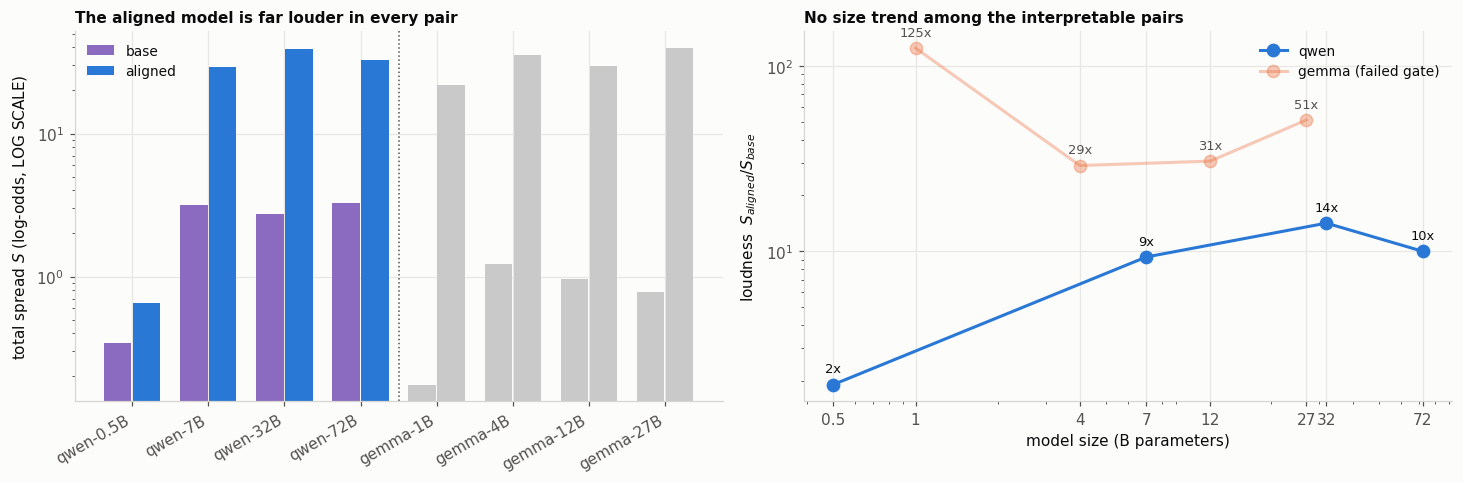

    model   fam  size  S_base  S_aligned  loudness  passes
qwen-0.5B  qwen   0.5    0.34       0.65      1.91    True
  qwen-7B  qwen   7.0    3.15      29.33      9.31    True
 qwen-32B  qwen  32.0    2.75      38.96     14.17    True
 qwen-72B  qwen  72.0    3.26      32.58     10.00    True
 gemma-1B gemma   1.0    0.18      21.89    124.67   False
 gemma-4B gemma   4.0    1.23      35.64     28.97   False
gemma-12B gemma  12.0    0.97      29.63     30.60   False
gemma-27B gemma  27.0    0.78      39.63     50.94   False

qwen 7B/32B/72B loudness: 9.3x, 14.2x, 10.0x   mean 11.2x
The ~9x from the single-model notebook holds up; 32B is a little higher at 14x.
qwen-0.5B is 1.9x, but both of its spreads are noise-sized, so read nothing into it.


In [9]:
ld = []
for pf, af, s in PAIRS:
    m = f"{af}-{s}B"
    cs = [c for c in CON if c in AVAIL[(pf, s)] and c in AVAIL[(af, s)]]
    Sb = np.mean([FITS[(pf, s, c)].total_spread() for c in cs])
    Sa = np.mean([FITS[(af, s, c)].total_spread() for c in cs])
    ld.append(dict(model=m, fam=af, size=float(s), S_base=Sb, S_aligned=Sa,
                   loudness=Sa / Sb, passes=m in PASSES))
L = pd.DataFrame(ld)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.5))
ax = axes[0]
x = np.arange(len(MODELS))
Lm = L.set_index("model").reindex(MODELS)
for i, (c, lab) in enumerate([("S_base", "base"), ("S_aligned", "aligned")]):
    ax.bar(x + (i - .5) * .38, Lm[c], .36, label=lab,
           color=[KIND_COLOR[lab] if ok else "#c9c9c9" for ok in Lm.passes], zorder=2)
ax.set_yscale("log")
ax.set_xticks(x, MODELS, rotation=30, ha="right")
ax.set_ylabel("total spread $S$ (log-odds, LOG SCALE)")
ax.set_title("The aligned model is far louder in every pair", loc="left",
             fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.axvline(3.5, color=INK_MUTED, lw=1, ls=":")

ax = axes[1]
for fam in ["qwen", "gemma"]:
    sub = Lm[Lm.fam == fam].sort_values("size")
    ax.plot(sub["size"], sub.loudness, "-o", color=FAM_COLOR[fam], lw=2, ms=8,
            alpha=1.0 if fam == "qwen" else .35,
            label=fam + ("" if fam == "qwen" else " (failed gate)"))
    for _, r in sub.iterrows():
        ax.annotate(f"{r.loudness:.0f}x", (r["size"], r.loudness), fontsize=8.5,
                    textcoords="offset points", xytext=(0, 8), ha="center",
                    color=INK if r.passes else INK_MUTED)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks([0.5, 1, 4, 7, 12, 27, 32, 72], ["0.5", "1", "4", "7", "12", "27", "32", "72"])
ax.set_xlabel("model size (B parameters)")
ax.set_ylabel(r"loudness  $S_{aligned} / S_{base}$")
ax.set_title("No size trend among the interpretable pairs", loc="left",
             fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
save(fig, "a3_loudness")
plt.show()

print(L.round(2).to_string(index=False))
q = L[L.passes & (L.model != "qwen-0.5B")]
print(f"\nqwen 7B/32B/72B loudness: {', '.join(f'{v:.1f}x' for v in q.loudness)}"
      f"   mean {q.loudness.mean():.1f}x")
print("The ~9x from the single-model notebook holds up; 32B is a little higher at 14x.")
print("qwen-0.5B is 1.9x, but both of its spreads are noise-sized, so read nothing into it.")

---
# Step 4 — adherence: do base models respond to the contract?

Same split as Fig 5.5 D. **AGREE** = 8GB vs 4GB, where obeying is free. **CONFLICT** = 8GB vs
16GB, where obeying costs a RAM step. Bars are the position-corrected win rate; the number above
each conflict bar is $\kappa$, the share of its own preference the model gave up.

For a base model "obeying" is not obedience — the prompt is a document in which the speaker has
already said *"I prefer 8 GB ram"*, and the model is completing it consistently. That is text
coherence, and it is exactly why this measure does not require an instruction-following model.

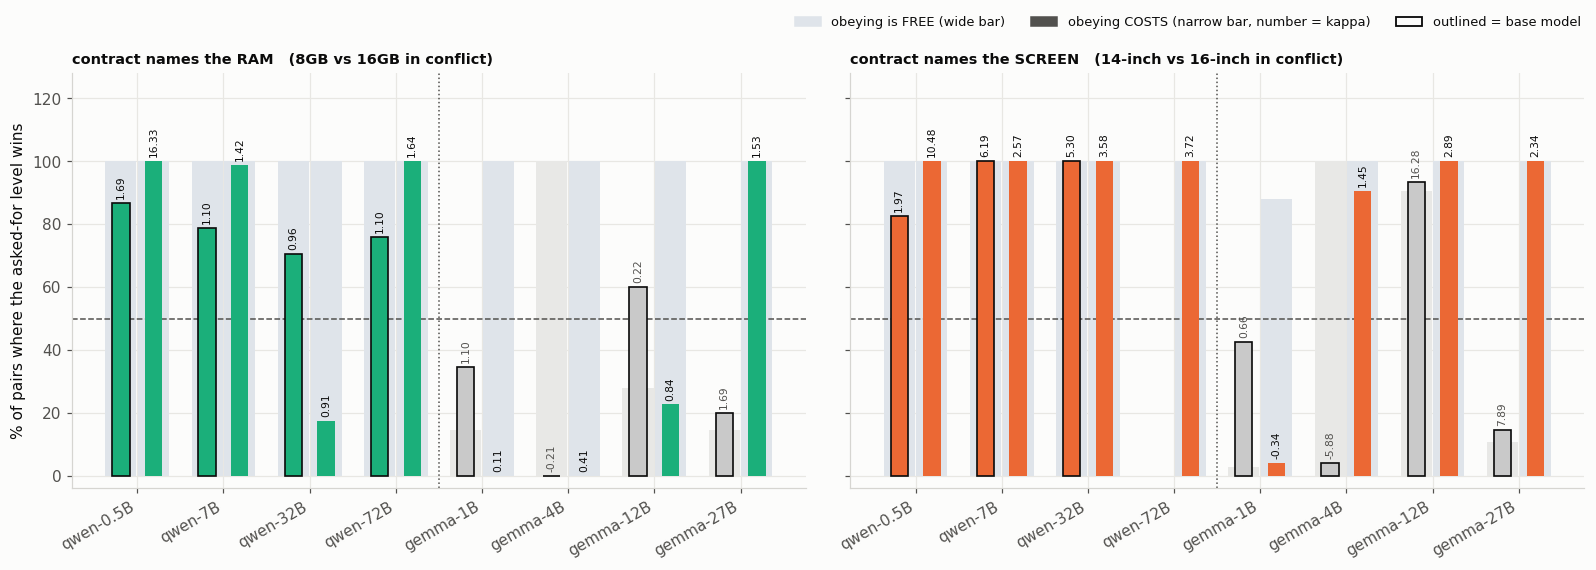

interpretable pairs only:

                  before          agree        conflict              g0         kappa      
kind             aligned   base aligned   base  aligned    base aligned  base aligned  base
feat   model                                                                               
ram    qwen-0.5B    9.33   0.00   100.0  100.0   100.00   86.67   -0.04 -0.12   16.33  1.69
       qwen-32B     0.00   0.00   100.0  100.0    17.33   70.67  -27.35 -2.01    0.91  0.96
       qwen-72B     0.00   0.00   100.0  100.0   100.00   76.00  -20.35 -1.78    1.64  1.10
       qwen-7B      0.00   0.00   100.0  100.0    98.67   78.67  -21.38 -1.94    1.42  1.10
screen qwen-0.5B   10.67   1.33   100.0  100.0   100.00   82.67   -0.04 -0.07   10.48  1.97
       qwen-32B     0.00   4.00   100.0  100.0   100.00  100.00  -10.07 -0.36    3.58  5.30
       qwen-72B     0.00    NaN   100.0    NaN   100.00     NaN   -7.80   NaN    3.72   NaN
       qwen-7B      0.00  12.00   100.0  100.0   100.

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14.6, 4.9), sharey=True)
for ax, feat in zip(axes, ["ram", "screen"]):
    sub = ADH[ADH.feat == feat]
    x = np.arange(len(MODELS))
    for i, kind in enumerate(["base", "aligned"]):
        t = sub[sub.kind == kind].set_index("model").reindex(MODELS)
        greyed = [m not in PASSES and kind == "base" for m in MODELS]
        ax.bar(x + (i - .5) * .38, t.agree, .36, zorder=2,
               color=["#e8e8e6" if g else "#dfe4ea" for g in greyed])
        ax.bar(x + (i - .5) * .38, t.conflict, .20, zorder=3,
               color=["#c9c9c9" if g else FEATURE_COLOR[feat] for g in greyed],
               edgecolor=INK if kind == "base" else "none", lw=1.1)
        for xi, (cf, kp, g) in enumerate(zip(t.conflict, t.kappa, greyed)):
            if np.isfinite(cf):
                ax.text(xi + (i - .5) * .38, cf + 2, f"{kp:.2f}", ha="center", fontsize=7,
                        rotation=90, color=INK_MUTED if g else INK)
    ax.axhline(50, color=INK_MUTED, ls="--", lw=1)
    ax.axvline(3.5, color=INK_MUTED, lw=1, ls=":")
    ax.set_xticks(x, MODELS, rotation=30, ha="right")
    ax.set_ylim(-4, 128)
    ax.set_title(f"contract names the {feat.upper()}   "
                 f"({ASKED[feat]} vs {RIVAL[feat]} in conflict)",
                 loc="left", fontweight="bold", fontsize=9.5)
axes[0].set_ylabel("% of pairs where the asked-for level wins")
fig.legend(handles=[Rectangle((0, 0), 1, 1, color="#dfe4ea"),
                    Rectangle((0, 0), 1, 1, color=INK_MUTED),
                    Rectangle((0, 0), 1, 1, fc="none", ec=INK, lw=1.2)],
           labels=["obeying is FREE (wide bar)", "obeying COSTS (narrow bar, number = kappa)",
                   "outlined = base model"],
           loc="upper right", ncol=3, frameon=False, fontsize=8.5, bbox_to_anchor=(.995, 1.06))
fig.tight_layout()
save(fig, "a4_adherence")
plt.show()

show = ADH[ADH.model.isin(PASSES)].pivot(index=["feat", "model"], columns="kind",
                                         values=["before", "agree", "conflict", "g0", "kappa"])
print("interpretable pairs only:\n")
print(show.round(2).to_string())

---
# Step 5 — is the Apple decay pretrained in every model?

Apple's weight as a share of the model's total spread, across the contract sequence. No contract
mentions brand, so any movement is the model filling in something the user never asked for.

If alignment *created* the effect, the base curves would be flat.

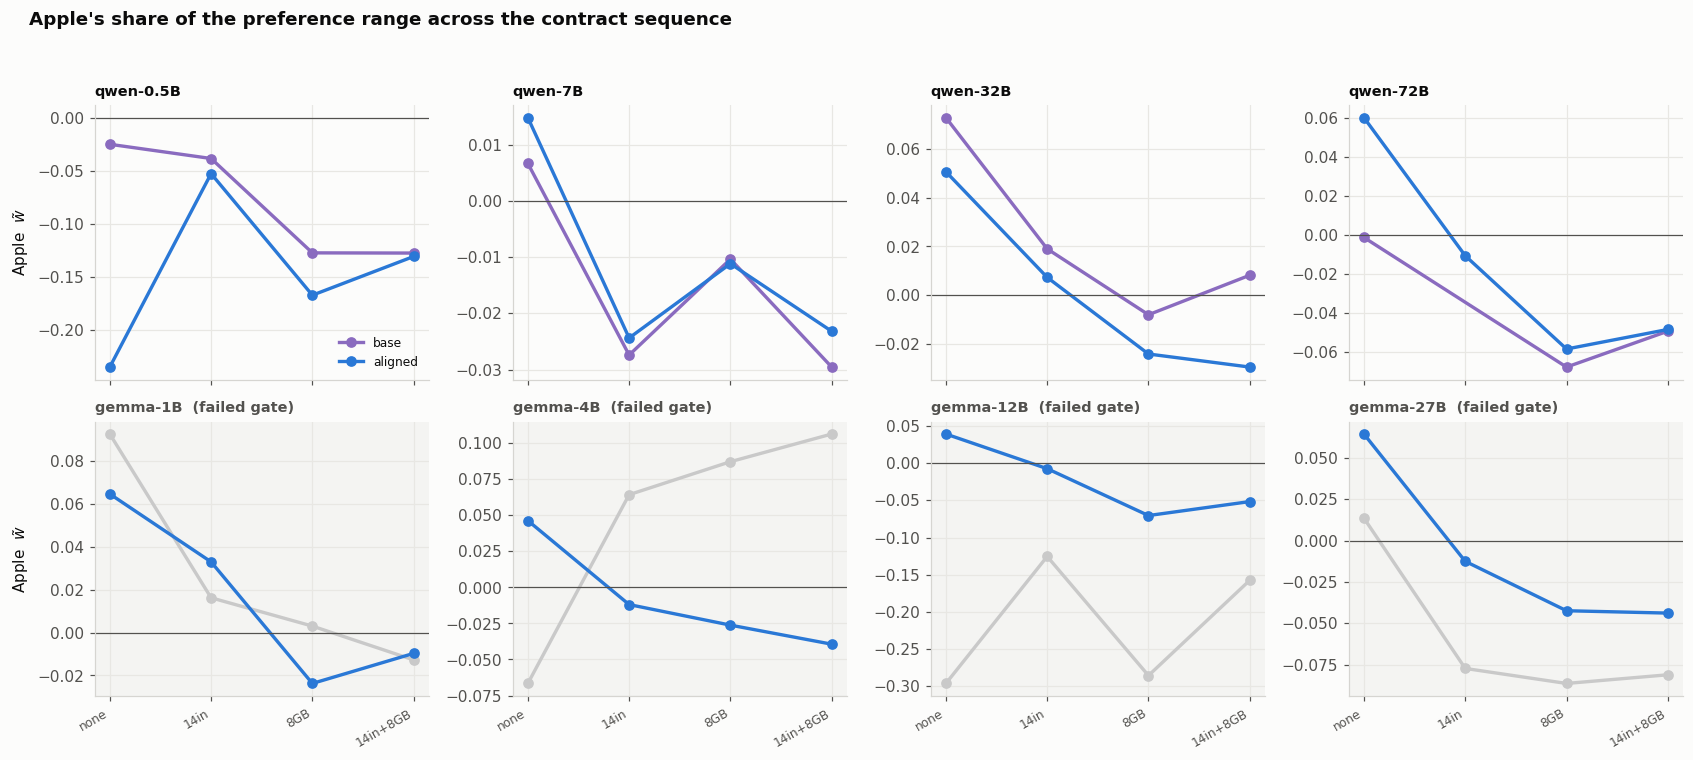

kind       aligned    base  passes
model                             
qwen-0.5B   0.1820  0.1023    True
qwen-7B     0.0392  0.0362    True
qwen-32B    0.0800  0.0808    True
qwen-72B    0.1185  0.0663    True
gemma-1B    0.0883  0.1053   False
gemma-4B    0.0858  0.1731   False
gemma-12B   0.1097  0.1709   False
gemma-27B   0.1081  0.0998   False

interpretable pairs - Apple swing, base vs aligned:
  base    0.102, 0.036, 0.081, 0.066
  aligned 0.182, 0.039, 0.080, 0.118
  correlation across the 4 pairs: +0.870


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(15.5, 7), sharex=True)
sw = []
for ax, (pf, af, s) in zip(axes.ravel(), PAIRS):
    m = f"{af}-{s}B"
    ok = m in PASSES
    for fam, kind in [(pf, "base"), (af, "aligned")]:
        cs = [c for c in CON if c in AVAIL[(fam, s)]]
        y = [FITS[(fam, s, c)].normalised("brand", "Apple") for c in cs]
        ax.plot([CON.index(c) for c in cs], y, "-o", ms=6, lw=2.2,
                color=KIND_COLOR[kind] if (ok or kind == "aligned") else "#c9c9c9",
                label=kind)
        sw.append(dict(model=m, kind=kind, swing=max(y) - min(y), passes=ok))
    ax.axhline(0, color=INK_MUTED, lw=.8)
    ax.set_xticks(range(4), cols, rotation=30, ha="right", fontsize=8)
    ax.set_title(m + ("" if ok else "  (failed gate)"), loc="left", fontweight="bold",
                 fontsize=9.5, color=INK if ok else INK_MUTED)
    if not ok:
        ax.set_facecolor("#f4f4f2")
axes[0, 0].set_ylabel(r"Apple  $\tilde{w}$")
axes[1, 0].set_ylabel(r"Apple  $\tilde{w}$")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Apple's share of the preference range across the contract sequence",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, .95])
save(fig, "a5_apple")
plt.show()

SW = pd.DataFrame(sw).pivot(index="model", columns="kind", values="swing").reindex(MODELS)
SW["passes"] = [m in PASSES for m in SW.index]
print(SW.round(4).to_string())
g = SW[SW.passes]
print(f"\ninterpretable pairs - Apple swing, base vs aligned:")
print(f"  base    {', '.join(f'{v:.3f}' for v in g.base)}")
print(f"  aligned {', '.join(f'{v:.3f}' for v in g.aligned)}")
print(f"  correlation across the {len(g)} pairs: "
      f"{st.pearsonr(g.base, g.aligned)[0]:+.3f}")

---
## What the new runs change

| claim | before (qwen-7B only) | now |
|---|---|---|
| scale-free weights agree | r = 0.990 | **replicates** for qwen-7B/32B/72B (0.990, 0.985, 0.982); qwen-0.5B weaker (0.833), both sides near the noise floor |
| alignment is a volume knob | ~9x | **9.3x, 14.2x, 10.0x** — holds, no size trend |
| the Apple decay is pretrained | one model | present in every qwen base model |
| gemma | untested | **still untested** — every gemma base model fails the gate |

**The gemma result is a measurement failure, not a negative finding.** Its base models answer by
slot position (92%, 99.8%, 12%, 0.6% of rows go to slot A regardless of content) and their
positional bias is ~2x their entire preference range. Nothing can be concluded about gemma's
pretrained preferences from these runs.

**The obvious next run.** When we picked the prompt format, the alternative was to keep the
instruct `options` templates for the base models too. qwen works fine with the `pretrained`
continuation format; gemma may simply not. Re-running the four `gemma-pt` models with
`--template_set options` would separate *"gemma base has no preferences"* from *"gemma base
cannot use this prompt format"* — 16 jobs, and it is the only way to rescue half this experiment.

Also outstanding: **qwen-pt 72B is missing its `screen=14-inch` run**, so it has no screen
adherence number and its correlation uses 33 points instead of 44.